In [2]:
import sys
sys.path.append('..')
import module
import pandas as pd

In [3]:
R = module.Rack(inventory_file = "salamander_inventory.csv", filename = "current.csv", euthanasia_log_file = "euthanasia_log.csv")

Temporary session directory created at <TemporaryDirectory '/var/folders/qk/0pp_4zdn44s_7tprcl4npjfw0000gn/T/tmpa7zzi982'>
Loaded existing inventory from salamander_inventory.csv


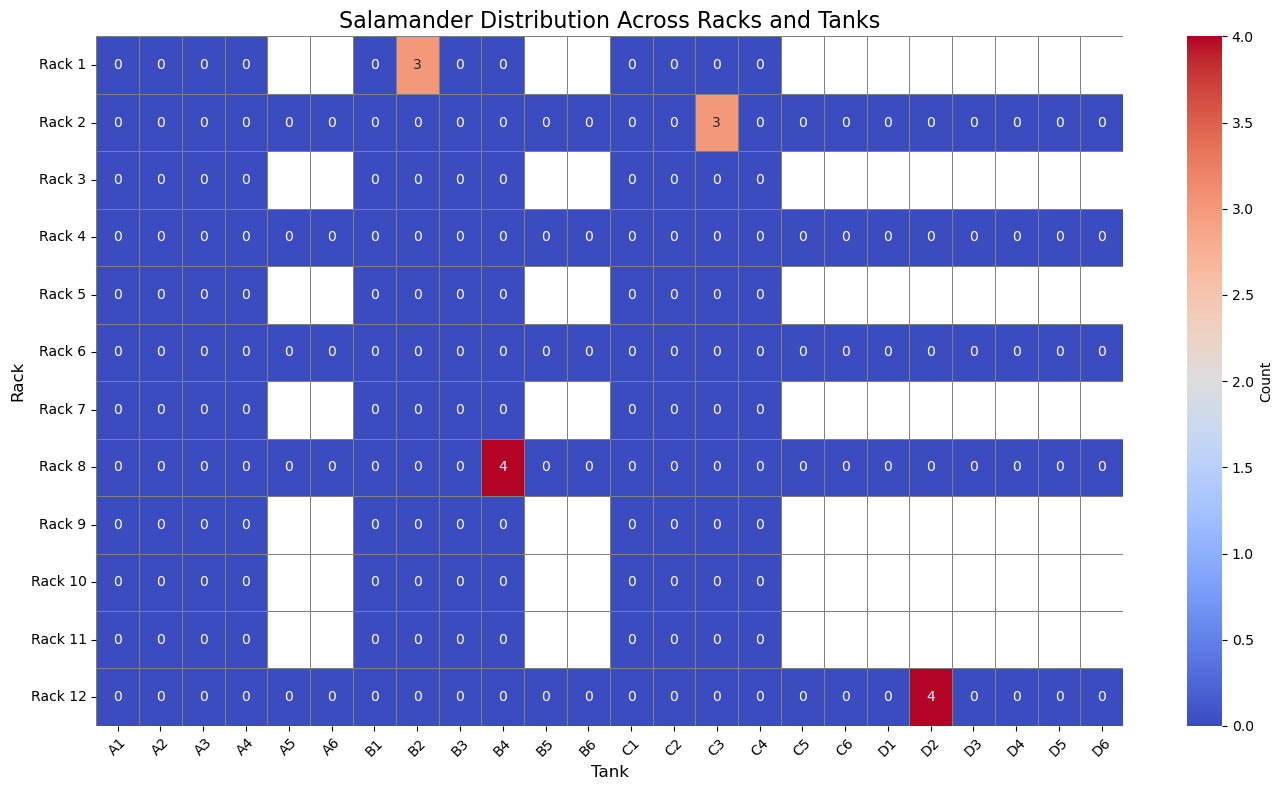

In [11]:
R.plot_rack_space()

In [19]:
R.inventory

,Animal_ID,Tank,Rack,DOB,Environmental_Condition,Sex,Lineage,Transgenic_Line,Experimental_Holds,Species,Protocol_Number,Experimental_History
0,SAL_001,B2,Rack 1,2021-09-05,Aquatic,NaN,Sweden,hsyn-GFP,False,Polypterus senegalus,AABL,EdU
1,SAL_002,B2,Rack 1,2024-02-03,Terrestrial,NaN,YxO,GCamP6s,False,Polypterus senegalus,AABY,EdU
2,SAL_003,B2,Rack 1,2022-02-09,Terrestrial,NaN,Sweden,Wildtype,True,Polypterus senegalus,AABI,Behavior Conditioning
3,SAL_005,C3,Rack 2,2024-06-21,Aquatic,Female,YxO,GCamP6s,True,Ambystoma mexicanum,AABL,Behavioral Study
4,SAL_006,C3,Rack 2,2022-01-16,Reaqua,NaN,Sweden,Wildtype,False,Pleurodeles waltl,AABL,Behavior Conditioning
5,SAL_007,D2,Rack 12,2024-01-22,Reaqua,NaN,Jungle Bobs,Wildtype,True,Polypterus senegalus,AABL,Regeneration
6,SAL_008,D2,Rack 12,2020-07-19,Reaqua,NaN,Jungle Bobs,hsyn-GFP,True,Ambystoma mexicanum,AABI,Viral injection
7,SAL_009,D2,Rack 12,2024-02-02,Reaqua,NaN,Sweden,hsyn-GFP,True,Polypterus senegalus,AABI,Viral injection
8,SAL_010,D2,Rack 12,2023-06-12,Aquatic,NaN,Jungle Bobs,GCamP6s,True,Polypterus senegalus,AABF,Behavior Conditioning
9,SAL_012,C3,Rack 2,2022-05-22,Aqua,NaN,PxO,GCaMP,,Pleurodeles waltl,AABL1550,NaN


In [6]:
R.add_salamanders(1, '2022-05-22', "Pleurodeles waltl", "hsyn-GCamP6s", "PxO", "AABL1550", "Rack 2", "A5", "Aqua", "Female", " ", "Edu")

1 new salamander(s) adding successfully.
Inventory saved to /Users/jamie/hacks/pleuro-parser/pleuro_parser/notebooks/salamander_inventory.csv.
Log successful
1 baby salamanders added to Rack 2, tank A5, with DOB 2022-05-22.


In [8]:
R.euthanize_animal('SAL_020','2025-4-12', 9, "Male", "Histology", "AOG", complications="found dead")

Log successful
Inventory saved to /Users/jamie/hacks/pleuro-parser/pleuro_parser/notebooks/salamander_inventory.csv.
Animal SAL_020 euthanized and removed from inventory.


In [9]:
R.euthanasia_log

[{'Animal ID': 'SAL_016',
  'Tank': 'A5',
  'Rack': 'Rack 3',
  'DOB': '2022-05-22',
  'Environmental Condition': 'Aqua',
  'Lineage': 'PxO',
  'Transgenic Line': 'hsyn-GCamP6s',
  'Experimental Holds': ' ',
  'Species': 'Pleurodeles waltl',
  'Protocol Number': 'AABL1550',
  'Experimental History': 'Edu',
  'DOD': '2025-4-12',
  'Weight (g)': 9,
  'Sex': 'Male',
  'Purpose': 'Histology',
  'Experimenter': 'AOG',
  'Complications': 'found dead'},
 {'Animal ID': 'SAL_013',
  'Tank': 'A5',
  'Rack': 'Rack 3',
  'DOB': '2022-05-22',
  'Environmental Condition': 'Aqua',
  'Lineage': 'PxO',
  'Transgenic Line': 'GCaMP',
  'Experimental Holds': ' ',
  'Species': 'Pleurodeles waltl',
  'Protocol Number': 'AABL1550',
  'Experimental History': nan,
  'DOD': '2025-4-12',
  'Weight (g)': 9,
  'Sex': 'Male',
  'Purpose': 'Histology',
  'Experimenter': 'AOG',
  'Complications': 'found dead'},
 {'Animal ID': 'SAL_018',
  'Tank': 'A6',
  'Rack': 'Rack 5',
  'DOB': '2022-05-22',
  'Environmental Condi

In [4]:
R.save_inventory()

Inventory saved to /Users/jamie/hacks/pleuro-parser/pleuro_parser/notebooks/salamander_inventory.csv.


In [9]:
R.save_state()

In [5]:
R.undo()

Undo successful.


In [11]:
R.move_salamander(["SAL_014", "SAL_015", "SAL_017", "SAL_019"], "Rack 8", "B4")

Animal SAL_014 moved to Rack 8.
B4
Log successful
Animal SAL_015 moved to Rack 8.
B4
Log successful
Animal SAL_017 moved to Rack 8.
B4
Log successful
Animal SAL_019 moved to Rack 8.
B4
Log successful
Inventory saved to /Users/jamie/hacks/pleuro-parser/pleuro_parser/notebooks/salamander_inventory.csv.


In [9]:
R.is_valid_tank("Rack 13", "D2")

False

In [11]:
R.edit_salamander_info(
    "SAL_005",
    **{
        "Environmental Condition": "Aquatic",  # Correct usage
        "Sex": "Female",
        "Protocol Number": "AABL",
        "Experimental History": "Behavioral Study"
    }
)

Inventory saved to /Users/jamie/hacks/pleuro-parser/pleuro_parser/notebooks/salamander_inventory.csv.
Log successful
Updated SAL_005:
 - Environmental Condition: Aquatic → Aquatic
 - Sex: Male → Female
 - Protocol Number: AABL → AABL
 - Experimental History: Behavioral Study → Behavioral Study


In [18]:
print(R.inventory.columns.tolist())


['Animal_ID', 'Tank', 'Rack', 'DOB', 'Environmental_Condition', 'Sex', 'Lineage', 'Transgenic_Line', 'Experimental_Holds', 'Species', 'Protocol_Number', 'Experimental_History']


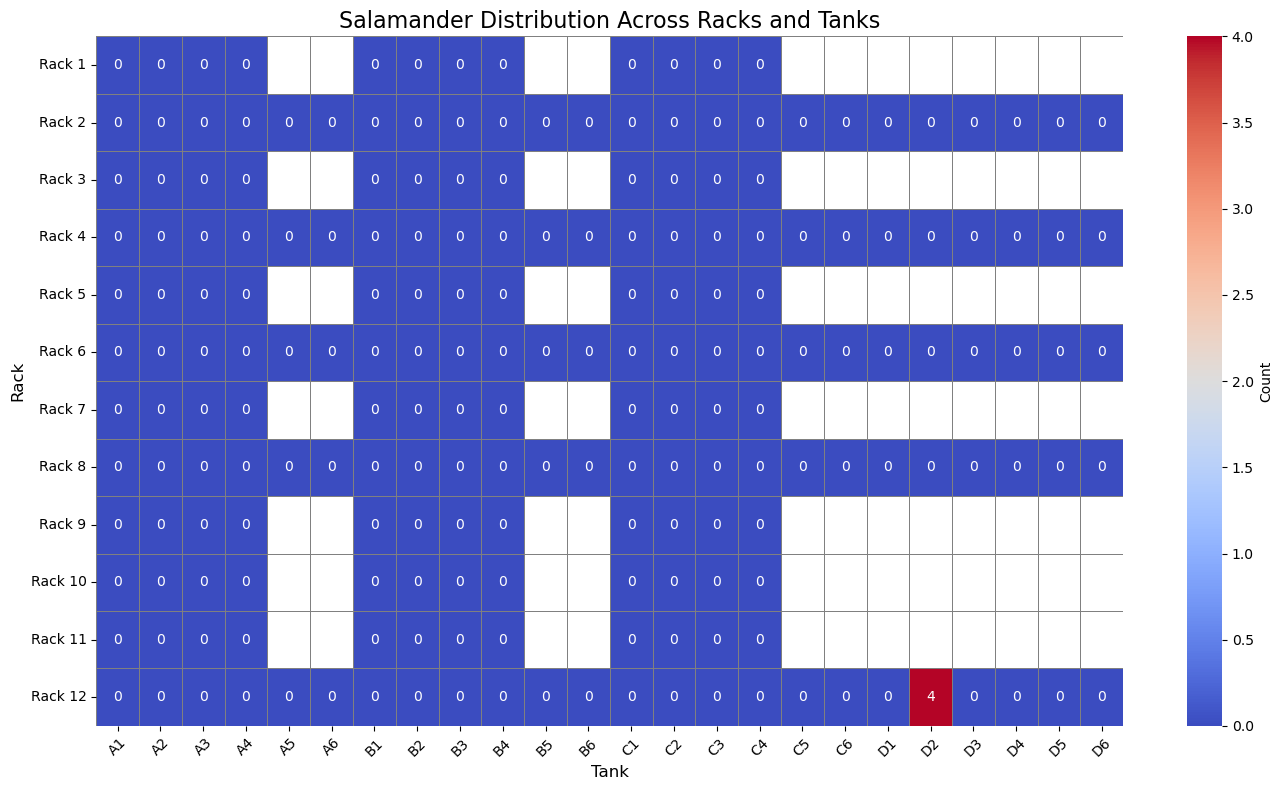

In [4]:
R.plot_rack_space()
#Build on this more - zooming in on one rack or one tank
#Maybe tie into search function
#maybe add color by species, by age range, by transgenic status, by no holds (change holds > who has hold or priority) 

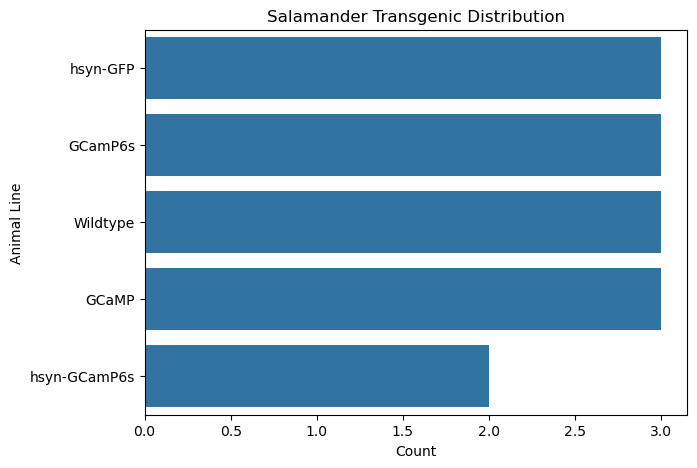

In [21]:
R.plot_transgenic_distribution()

In [ ]:
#add larval euthanasia log? 

In [16]:
R.search_salamanders(Transgenic\Line = "Pleurodeles waltl")
#Cant find by column names if there is a space/multiple words
#returns females as partial match to male
#Add a summary of number of animals?

SyntaxError: unexpected character after line continuation character (1109835438.py, line 1)

In [10]:
criteria = {
    "Environmental Condition": "Aquatic",
    "Protocol Number": "AABL"
}
R.search_salamanders(**criteria)
#Options for fixing issue - if adding _ to colnames need to update in module where nececssary
#self.inventory.columns = [col.replace(" ", "_") for col in self.inventory.columns]

,Animal ID,Tank,Rack,DOB,Environmental Condition,Sex,Lineage,Transgenic Line,Experimental Holds,Species,Protocol Number,Experimental History
0,SAL_001,B2,Rack 1,2021-09-05,Aquatic,NaN,Sweden,hsyn-GFP,False,Polypterus senegalus,AABL,EdU
3,SAL_005,C3,Rack 2,2024-06-21,Aquatic,Female,YxO,GCamP6s,True,Ambystoma mexicanum,AABL,Behavioral Study


In [17]:
R.analyze_euthanasia_log()
#add by experimenter 

,Protocol Number,Year,total_euthanized,complications
0,AABL1550,2025,4,4


In [15]:
"""To do: 
-add more plotting features?
-update readme
-start building webapp with streamlit
"""

'To add: '

In [20]:
summary = R.analyze_euthanasia_log()
print(summary)

  Protocol Number  Year  total_euthanized  complications
0        AABL1550  2025                 2              2


In [17]:
R.inventory.rename(columns={"Experimental Holds": "Experimental_Holds"}, inplace=True)